# Objective:
# 1. Visualize stock data
# 2. Understand price movement and returns
# 3. Build intuition from charts

In [1]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("../data/bhavcopy.csv")

df.columns = df.columns.str.strip() # it removes any leading or trailing whitespace from the column names

In [25]:
df["DATE1"] = pd.to_datetime(df["DATE1"]) # it converts the DATE column to datetime format
#df.set_index("DATE1", inplace=True) # it sets the DATE column as the index

In [20]:
df.columns

Index(['SYMBOL', 'SERIES', 'PREV_CLOSE', 'OPEN_PRICE', 'HIGH_PRICE',
       'LOW_PRICE', 'LAST_PRICE', 'CLOSE_PRICE', 'AVG_PRICE', 'TTL_TRD_QNTY',
       'TURNOVER_LACS', 'NO_OF_TRADES', 'DELIV_QTY', 'DELIV_PER'],
      dtype='object')

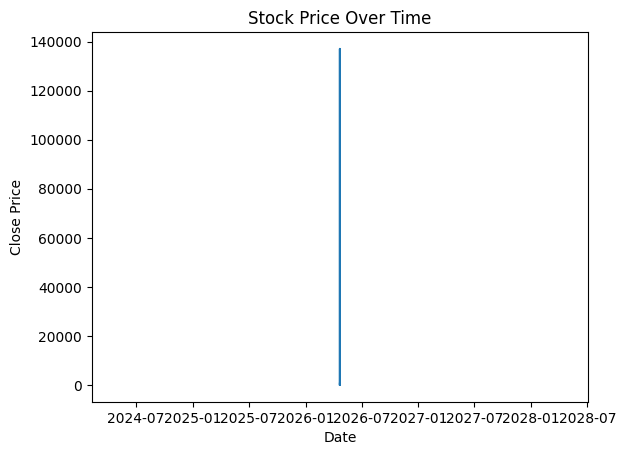

In [26]:
plt.figure()

plt.plot(df["DATE1"], df["CLOSE_PRICE"])

plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

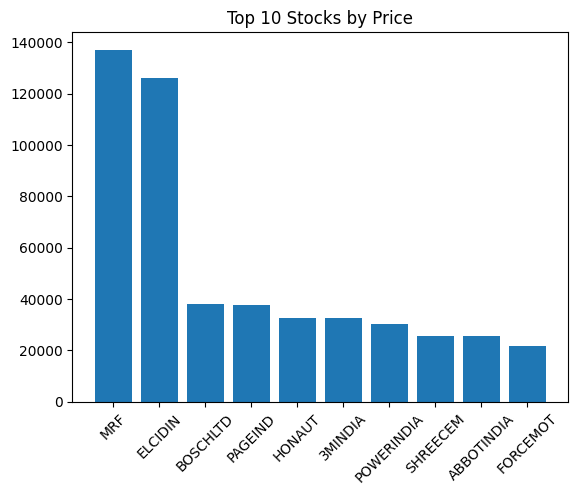

In [28]:
top = df.sort_values(by="CLOSE_PRICE", ascending=False).head(10)

plt.figure()

plt.bar(top["SYMBOL"], top["CLOSE_PRICE"])

plt.title("Top 10 Stocks by Price")
plt.xticks(rotation=45)

plt.show()

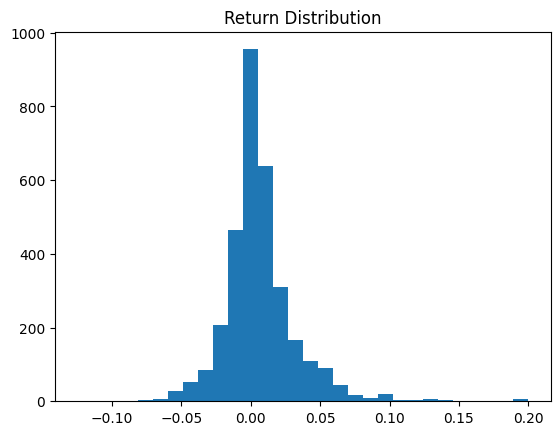

In [29]:
# create return column first
df["RETURN"] = (df["CLOSE_PRICE"] - df["PREV_CLOSE"]) / df["PREV_CLOSE"]

plt.figure()

plt.hist(df["RETURN"].dropna(), bins=30)

plt.title("Return Distribution")

plt.show()

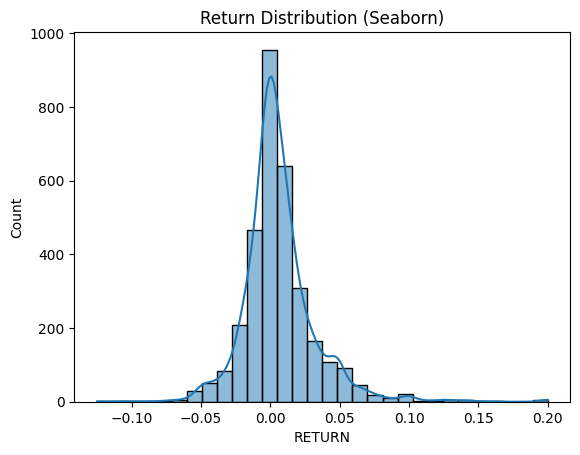

In [30]:
sns.histplot(df["RETURN"].dropna(), bins=30, kde=True)

plt.title("Return Distribution (Seaborn)")

plt.show()

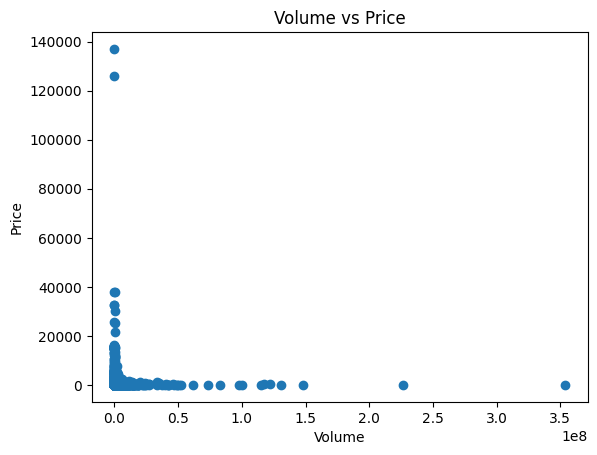

In [31]:
plt.figure()

plt.scatter(df["TTL_TRD_QNTY"], df["CLOSE_PRICE"])

plt.xlabel("Volume")
plt.ylabel("Price")

plt.title("Volume vs Price")

plt.show()

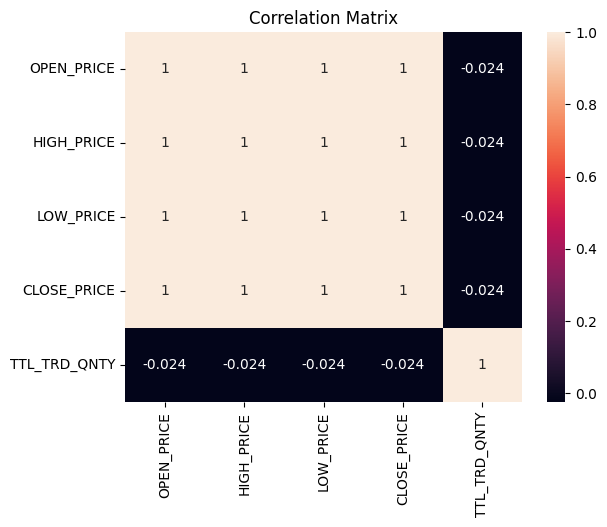

In [32]:
corr = df[[
    "OPEN_PRICE",
    "HIGH_PRICE",
    "LOW_PRICE",
    "CLOSE_PRICE",
    "TTL_TRD_QNTY"
]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

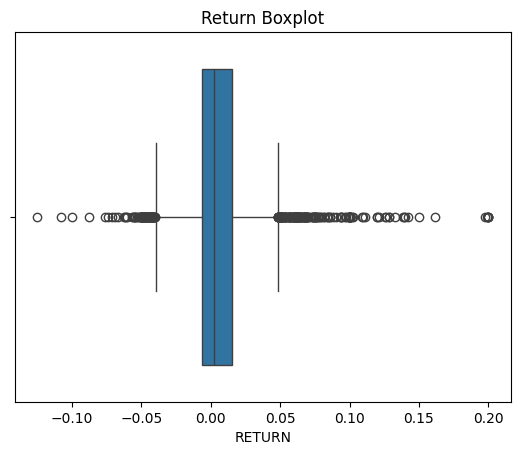

In [33]:
sns.boxplot(x=df["RETURN"])

plt.title("Return Boxplot")

plt.show()

In [ ]:
# Insights:
# 1. Price distribution shows variation across stocks
# 2. Return histogram highlights volatility
# 3. Scatter plot helps understand volume-price relationship
# 4. Correlation shows strong linkage between OHLC values
# 5. Outliers indicate extreme market movements